# Seismic Sensor Placement — QUBO / QAOA vs CP-SAT
**Deliverable**: ranked deployment table for the multi-hazard optimisation kernel (Liz's memo, Phase II).

## Pipeline
```
USGS + SSN  →  seismicity density grid  →  risk weights wᵢ
EarthScope Fedcatalog  →  existing station inventory  →  greenfield flags
         ↓
  8-12 candidate locations  +  CAPEX cᵢ
         ↓
  QUBO: maximise Σwᵢxᵢ  s.t. Σcᵢxᵢ ≤ B,  xᵢ∈{0,1}
         ↓                                  ↓
  QAOA (PennyLane)               OR-Tools CP-SAT (exact)
         ↓                                  ↓
              Ranked deployment table  +  agreement analysis
```

**Key constraint**: ≤ 20 binary variables so the simulator runs cleanly (2²⁰ < 10⁶ states).

In [ ]:
%pip -q install pennylane requests pandas scipy ortools matplotlib pydantic pyyaml


In [ ]:
import sys, io, pathlib, json, requests, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from scipy.optimize import minimize
import pennylane as qml

# ── Add manzanillo_qc package to path ─────────────────────────────────────────
# The package lives at manzanillo-qc/src/ relative to this notebook.
_pkg_path = pathlib.Path("manzanillo-qc/src").resolve()
if str(_pkg_path) not in sys.path:
    sys.path.insert(0, str(_pkg_path))

warnings.filterwarnings('ignore')
np.random.seed(42)
print(f"PennyLane {qml.__version__}")
print(f"manzanillo_qc path: {_pkg_path}")


## §1  Data Sources

Three sources feed into the risk-weight calculation.  All have confirmed-working endpoints (from `data_catalog_QA_notebook_clean.ipynb`).

In [14]:
# ── USGS Earthquake Catalog ─────────────────────────────────────────────────
MINLAT, MAXLAT =  18.0,  20.0
MINLON, MAXLON = -105.0, -100.0
START, END     = "2005-01-01", "2025-01-01"
MINMAG         =  2.0           # all magnitudes for density map
API_LIMIT      = 19_000

BASE = "https://earthquake.usgs.gov/fdsnws/event/1/query"

def usgs_page(start, end, offset=1):
    r = requests.get(BASE, params=dict(
        format="geojson", minlatitude=MINLAT, maxlatitude=MAXLAT,
        minlongitude=MINLON, maxlongitude=MAXLON,
        starttime=start, endtime=end, minmagnitude=MINMAG,
        orderby="time-asc", limit=API_LIMIT, offset=offset,
    ), timeout=60)
    r.raise_for_status()
    return r.json()

def geojson_to_df(obj):
    rows = [{"time": pd.to_datetime(f["properties"]["time"], unit="ms", utc=True),
             "mag":  f["properties"].get("mag"),
             "lon":  f["geometry"]["coordinates"][0],
             "lat":  f["geometry"]["coordinates"][1],
             "depth":f["geometry"]["coordinates"][2]}
            for f in obj.get("features", [])]
    return pd.DataFrame(rows)

frames, offset = [], 1
while True:
    print(f"  USGS offset={offset} …", end=" ")
    obj = usgs_page(START, END, offset=offset)
    chunk = geojson_to_df(obj)
    print(f"{len(chunk)} events")
    frames.append(chunk)
    if len(chunk) < API_LIMIT:
        break
    offset += API_LIMIT

usgs = pd.concat(frames, ignore_index=True).dropna(subset=["mag"])
usgs = usgs.sort_values("time").reset_index(drop=True)
print(f"\nUSGS total: {len(usgs):,}  M {usgs.mag.min():.1f}–{usgs.mag.max():.1f}")
usgs.head(3)

  USGS offset=1 … 498 events

USGS total: 498  M 2.6–7.6


,time,mag,lon,lat,depth
0,2005-01-18 15:36:18.100000+00:00,3.7,-100.635,18.268,68.5
1,2005-01-25 08:38:08.700000+00:00,3.7,-103.659,18.519,15.0
2,2005-02-02 07:17:43.700000+00:00,3.7,-104.253,18.800,18.1


In [ ]:
# ── SSN Catálogo de sismos ──────────────────────────────────────────────────
# Try the CSV export endpoint. Falls back to using USGS-only if unavailable.
import datetime as dt

ssn = pd.DataFrame()  # stays empty if endpoint fails
try:
    end_d   = dt.date.today()
    start_d = end_d - dt.timedelta(days=365*15)   # 15 years
    csv_url = (f"http://www2.ssn.unam.mx:8080/catalogo/reportecsv"
               f"?inicio={start_d}&fin={end_d}")
    r = requests.get(csv_url, timeout=30, headers={"User-Agent":"qa/1.0"})
    if r.status_code == 200 and r.text.strip():
        lines = [l for l in r.text.splitlines() if l.strip()]
        # SSN CSV: Fecha,Hora,Latitud,Longitud,Profundidad,Magnitud,...
        if len(lines) > 1 and "," in lines[0]:
            ssn = pd.read_csv(io.StringIO(r.text), on_bad_lines="skip")
            # Normalise column names
            ssn.columns = [c.strip().lower() for c in ssn.columns]
            lat_col = next((c for c in ssn.columns if "lat" in c), None)
            lon_col = next((c for c in ssn.columns if "lon" in c), None)
            mag_col = next((c for c in ssn.columns if "mag" in c), None)
            if lat_col and lon_col and mag_col:
                ssn = ssn.rename(columns={lat_col:"lat", lon_col:"lon", mag_col:"mag"})
                ssn = ssn[["lat","lon","mag"]].dropna()
                ssn = ssn[(ssn.lat.between(MINLAT,MAXLAT)) &
                          (ssn.lon.between(MINLON,MAXLON))]
                print(f"SSN: {len(ssn)} events in region")
            else:
                ssn = pd.DataFrame()
    if ssn.empty:
        print("SSN: endpoint returned non-CSV data — using USGS only (documented data gap).")
except Exception as e:
    print(f"SSN: fetch failed ({e}) — using USGS only.")

# Merge: add SSN coords to USGS if available
if not ssn.empty:
    ssn_extra = ssn[~ssn.lat.round(2).isin(usgs.lat.round(2))].copy()
    ssn_extra["source"] = "SSN"
    usgs["source"] = "USGS"
    catalog = pd.concat([usgs, ssn_extra[["lat","lon","mag","source"]]], ignore_index=True)
    print(f"Combined catalog: {len(catalog):,} events")
else:
    catalog = usgs.copy()
    catalog["source"] = "USGS"
    print(f"Catalog (USGS only): {len(catalog):,} events")


In [16]:
# ── EarthScope Fedcatalog / FDSN station inventory ──────────────────────────
# Query for existing seismic stations near Manzanillo/Colima.
# These define which grid cells already have coverage (greenfield vs redundant).

FDSN_STATION = "https://service.iris.edu/fdsnws/station/1/query"
stations = pd.DataFrame(columns=["network","station","lat","lon","elev","site"])

try:
    r = requests.get(FDSN_STATION, params=dict(
        minlatitude=MINLAT-1, maxlatitude=MAXLAT+1,
        minlongitude=MINLON-1, maxlongitude=MAXLON+1,
        level="station", format="text",
    ), timeout=30, headers={"User-Agent":"qa/1.0"})
    if r.status_code == 200:
        lines = [l for l in r.text.splitlines() if l.strip() and not l.startswith("#")]
        rows = []
        for ln in lines:
            parts = [p.strip() for p in ln.split("|")]
            if len(parts) >= 6:
                try:
                    rows.append({"network": parts[0], "station": parts[1],
                                 "lat": float(parts[2]), "lon": float(parts[3]),
                                 "elev": float(parts[4]), "site": parts[5]})
                except ValueError:
                    pass
        stations = pd.DataFrame(rows)
        # Keep only stations inside the study bbox
        stations = stations[(stations.lat.between(MINLAT, MAXLAT)) &
                            (stations.lon.between(MINLON, MAXLON))].reset_index(drop=True)
        print(f"Existing stations in study bbox: {len(stations)}")
        if len(stations):
            print(stations[["network","station","lat","lon","site"]].to_string(index=False))
except Exception as e:
    print(f"FDSN station query failed: {e}")
    print("Proceeding without existing-station overlay.")

Existing stations in study bbox: 66
network station       lat         lon              site
     MX    MOIG 19.646708 -101.227303 Morelia, Mich, MX
     SY    MOIG 19.646708 -101.227303    MOIG synthetic
     XF    MA01 18.901400 -103.911201               M01
     XF    MA02 18.627300 -103.673401               M02
     XF    MA04 18.688499 -103.299004               M04
     XF    MA05 18.923599 -103.125000               M05
     XF    MA06 18.146099 -102.879799               M06
     XF    MA07 18.893299 -102.794296               M07
     XF    MA08 18.531799 -103.004501               M08
     XF    MA09 18.062500 -102.656700               M09
     XF    MA11 18.427099 -102.344002               M11
     XF    MA12 18.781200 -102.190598               M12
     XF    MA14 19.238501 -103.418999               M14
     XF    MA15 19.098499 -102.286301               M15
     XF    MA16 19.977800 -103.253998               M16
     XF    MA17 19.489799 -102.032997               M17
     XF    M

## §2  Seismicity Density Grid + Risk Weights (classical)

Grid: 4 lat-bins × 5 lon-bins = 20 cells over 18–20°N, 100–105°W.

Risk score per cell uses energy-weighted density:
```
score_i = Σ_{events in cell i}  10^(1.5 · M)     ← proportional to seismic moment
```
Normalised to [0, 1].

In [17]:
N_LAT, N_LON = 4, 5
lat_edges = np.linspace(MINLAT, MAXLAT, N_LAT+1)
lon_edges = np.linspace(MINLON, MAXLON, N_LON+1)

lat_centres = 0.5*(lat_edges[:-1] + lat_edges[1:])
lon_centres = 0.5*(lon_edges[:-1] + lon_edges[1:])

# Build grid DataFrame
grid_rows = []
for i, lat_c in enumerate(lat_centres):
    for j, lon_c in enumerate(lon_centres):
        mask = ((catalog.lat  >= lat_edges[i])   & (catalog.lat  < lat_edges[i+1]) &
                (catalog.lon  >= lon_edges[j])   & (catalog.lon  < lon_edges[j+1]))
        ev = catalog[mask]
        n_events = len(ev)
        energy   = float(ev.mag.apply(lambda m: 10**(1.5*m)).sum()) if n_events else 0.0
        grid_rows.append({
            "cell": f"R{i}C{j}", "lat_c": lat_c, "lon_c": lon_c,
            "lat_bin": i, "lon_bin": j,
            "n_events": n_events, "energy": energy,
        })

grid = pd.DataFrame(grid_rows)
grid["risk_raw"]  = grid["energy"]
grid["risk_norm"] = (grid["risk_raw"] / grid["risk_raw"].max()).round(4)

# Flag cells that already have a station
grid["has_station"] = False
if len(stations):
    for _, st in stations.iterrows():
        ii = np.searchsorted(lat_edges[1:], st.lat)
        jj = np.searchsorted(lon_edges[1:], st.lon)
        if 0 <= ii < N_LAT and 0 <= jj < N_LON:
            grid.loc[(grid.lat_bin==ii)&(grid.lon_bin==jj), "has_station"] = True

print(grid[["cell","lat_c","lon_c","n_events","risk_norm","has_station"]].to_string(index=False))

cell  lat_c  lon_c  n_events  risk_norm  has_station
R0C0  18.25 -104.5        13     0.0008        False
R0C1  18.25 -103.5        79     0.0035         True
R0C2  18.25 -102.5        56     1.0000         True
R0C3  18.25 -101.5        84     0.0028        False
R0C4  18.25 -100.5        79     0.0073        False
R1C0  18.75 -104.5        32     0.0042        False
R1C1  18.75 -103.5        28     0.0018         True
R1C2  18.75 -102.5        24     0.0004         True
R1C3  18.75 -101.5        31     0.0086        False
R1C4  18.75 -100.5         5     0.0001        False
R2C0  19.25 -104.5        27     0.0026         True
R2C1  19.25 -103.5         9     0.0001         True
R2C2  19.25 -102.5        10     0.0001         True
R2C3  19.25 -101.5         0     0.0000        False
R2C4  19.25 -100.5         4     0.0000        False
R3C0  19.75 -104.5         3     0.0000         True
R3C1  19.75 -103.5         1     0.0000         True
R3C2  19.75 -102.5         6     0.0000       

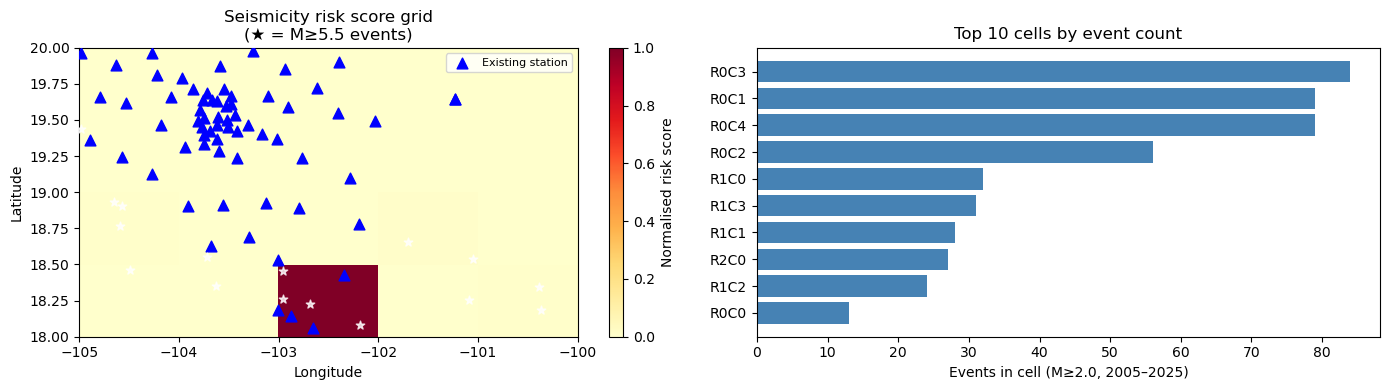

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Risk heatmap ──────────────────────────────────────────────────────────────
ax = axes[0]
Z = grid.pivot(index="lat_bin", columns="lon_bin", values="risk_norm").values[::-1]
im = ax.imshow(Z, cmap="YlOrRd", vmin=0, vmax=1,
               extent=[MINLON, MAXLON, MINLAT, MAXLAT], aspect="auto")
plt.colorbar(im, ax=ax, label="Normalised risk score")

# Overlay existing stations
if len(stations):
    ax.scatter(stations.lon, stations.lat, c="blue", s=60, marker="^",
               zorder=5, label="Existing station")
    ax.legend(fontsize=8)

# Overlay large events
big = catalog[catalog.mag >= 5.5]
ax.scatter(big.lon, big.lat, c="white", s=40, marker="*", zorder=6, alpha=0.8)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Seismicity risk score grid\n(★ = M≥5.5 events)")
ax.set_xlim(MINLON, MAXLON); ax.set_ylim(MINLAT, MAXLAT)

# ── Event count bar ───────────────────────────────────────────────────────────
ax2 = axes[1]
top = grid.nlargest(10, "n_events")
ax2.barh(top["cell"], top["n_events"], color="steelblue")
ax2.set_xlabel("Events in cell (M≥2.0, 2005–2025)")
ax2.set_title("Top 10 cells by event count")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

## §3  Candidate Sensor Locations + CAPEX

Select **8 candidate locations** from the grid:
- Top 5 cells by risk score → highest deployment priority
- 3 lower-risk cells → needed to test budget trade-offs

CAPEX estimates (rough, from EarthScope sensor inventory + literature):
| Sensor type | CAPEX ($K) | Use case |
|---|---|---|
| Broadband seismometer | 80–120 | High-risk, permanent network |
| Short-period seismometer | 50–70 | Medium-risk, regional |
| MEMS node | 20–40 | Low-cost infill / temporary |

In [19]:
# Select 5 high-risk + 3 lower-risk cells
top5   = grid.nlargest(5, "risk_norm").copy()
rest   = grid[~grid.index.isin(top5.index)]
low3   = rest.nsmallest(3, "risk_norm").nlargest(3, "n_events").copy()  # low risk but some activity
candidates = pd.concat([top5, low3], ignore_index=True).reset_index(drop=True)

# Assign CAPEX based on risk tier (in $10 K units, i.e. ×10 = dollars × 10^3)
def capex(row):
    if row.risk_norm >= 0.6:   return 10   # broadband  ~$100K
    elif row.risk_norm >= 0.3: return  7   # short-period ~$70K
    else:                      return  4   # MEMS ~$40K

candidates["capex_10k"] = candidates.apply(capex, axis=1)
candidates["sensor_type"] = candidates["capex_10k"].map({10:"Broadband",7:"Short-period",4:"MEMS"})
candidates["greenfield"] = ~candidates["has_station"]

# Rename for clarity
candidates["name"] = candidates.apply(lambda r: f"Loc-{r.name+1} ({r.lat_c:.2f}°N,{r.lon_c:.2f}°W)", axis=1)

BUDGET_10K = 25   # $250 K total deployment budget
print(f"Budget: ${BUDGET_10K*10}K = {BUDGET_10K} units")
print(f"Min possible sensors: {BUDGET_10K // candidates.capex_10k.max()}")
print(f"Max possible sensors: {BUDGET_10K // candidates.capex_10k.min()}\n")
print(candidates[["name","risk_norm","capex_10k","sensor_type","greenfield"]].to_string(index=False))

Budget: $250K = 25 units
Min possible sensors: 2
Max possible sensors: 6

                     name  risk_norm  capex_10k sensor_type  greenfield
Loc-1 (18.25°N,-102.50°W)     1.0000         10   Broadband       False
Loc-2 (18.75°N,-101.50°W)     0.0086          4        MEMS        True
Loc-3 (18.25°N,-100.50°W)     0.0073          4        MEMS        True
Loc-4 (18.75°N,-104.50°W)     0.0042          4        MEMS        True
Loc-5 (18.25°N,-103.50°W)     0.0035          4        MEMS       False
Loc-6 (19.25°N,-100.50°W)     0.0000          4        MEMS        True
Loc-7 (19.75°N,-104.50°W)     0.0000          4        MEMS       False
Loc-8 (19.25°N,-101.50°W)     0.0000          4        MEMS        True


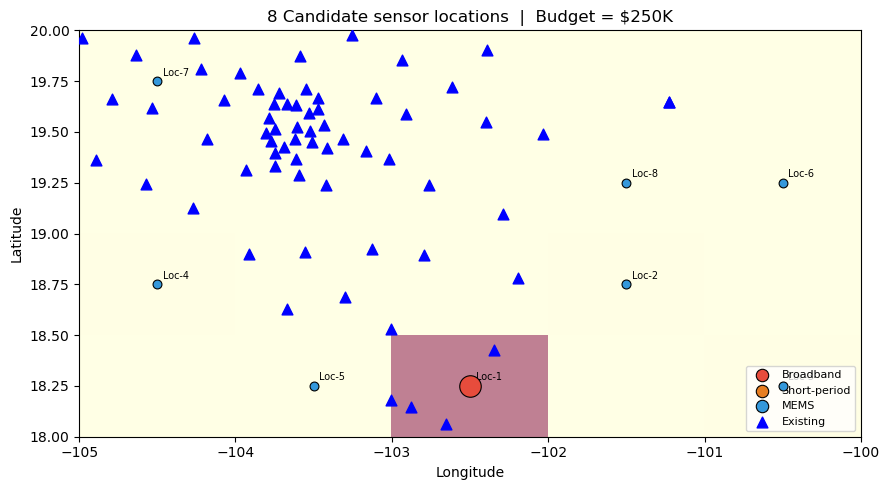

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))

# Background risk grid
Z = grid.pivot(index="lat_bin", columns="lon_bin", values="risk_norm").values[::-1]
ax.imshow(Z, cmap="YlOrRd", vmin=0, vmax=1, alpha=0.5,
          extent=[MINLON, MAXLON, MINLAT, MAXLAT], aspect="auto")

# Candidate locations — sized by risk, coloured by sensor type
type_colors = {"Broadband": "#e74c3c", "Short-period": "#e67e22", "MEMS": "#3498db"}
for _, row in candidates.iterrows():
    c = type_colors[row.sensor_type]
    ax.scatter(row.lon_c, row.lat_c, s=200*row.risk_norm+40, c=c,
               edgecolors="black", linewidths=0.8, zorder=6)
    ax.annotate(row["name"].split("(")[0].strip(),
                (row.lon_c, row.lat_c), textcoords="offset points",
                xytext=(4,4), fontsize=7)

# Legend
for t, c in type_colors.items():
    ax.scatter([], [], c=c, s=80, edgecolors="black", lw=0.8, label=t)
if len(stations):
    ax.scatter(stations.lon, stations.lat, marker="^", c="blue", s=60, zorder=7, label="Existing")
ax.legend(fontsize=8, loc="lower right")

ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"8 Candidate sensor locations  |  Budget = ${BUDGET_10K*10}K")
ax.set_xlim(MINLON, MAXLON); ax.set_ylim(MINLAT, MAXLAT)
plt.tight_layout()
plt.show()

## §4  QUBO Formulation  *(via `manzanillo_qc.qubo`)*

**Binary variables**: x = [x₀,…,x₇] — one bit per candidate location (8 total).

**Objective** (minimise, since QAOA minimises):
```
f(x) = −Σᵢ wᵢ xᵢ  +  λ · (Σᵢ cᵢ xᵢ − B)²
```
The penalty term penalises budget violation.  No slack bits are needed because
the constraint is enforced as a soft penalty — this keeps the qubit count at **n = 8**
(vs. n + K_slack = 13 in the inline version).

**QUBO matrix Q** (upper triangular):
```
Q[i,i] = −wᵢ  +  λ·cᵢ·(cᵢ − 2B)
Q[i,j] =          2λ·cᵢ·cⱼ          (i < j)
```

**λ choice**: `λ = 1 + Σ wᵢ`  — any infeasible solution costs more than the maximum
possible objective (since Σwᵢ ≤ 1 + Σwᵢ = λ by construction).

**Ising Hamiltonian** (from substituting xᵢ = (1−σᵢ)/2):
```
hᵢ  = −Q[i,i]/2  −  (1/4)·Σⱼ≠ᵢ Q[min(i,j),max(i,j)]
Jᵢⱼ = Q[i,j] / 4
```


In [ ]:
from manzanillo_qc.config import AppConfig, SiteCandidate
from manzanillo_qc.qubo import build_qubo, brute_force

# ── Build AppConfig from the candidates DataFrame ──────────────────────────────
cfg = AppConfig(
    budget_10k=BUDGET_10K,
    p_layers=2,
    n_steps=200,
    stepsize=0.01,
    backend="default.qubit",
    sites=[
        SiteCandidate(
            name=str(row["name"]),
            lat=float(row.lat_c),
            lon=float(row.lon_c),
            risk_weight=float(row.risk_norm),
            capex_10k=int(row.capex_10k),
            sensor_type=str(row.sensor_type),
            greenfield=bool(row.greenfield),
        )
        for _, row in candidates.iterrows()
    ],
)

# ── Build QUBO matrix ──────────────────────────────────────────────────────────
Q, meta = build_qubo(cfg)

# Expose variables needed by downstream cells
n_sensors = cfg.n_sites
n_vars    = n_sensors          # no slack bits — Q is n×n (8×8)
w = cfg.weights
c = cfg.costs
B = float(cfg.budget_10k)

print(f"λ = {meta['lambda']:.3f}  (> Σwᵢ = {w.sum():.3f} ✓)")
print(f"Variables: {n_sensors} sensor bits (no slack)  |  2^{n_sensors} = {2**n_sensors} states")
print(f"Q range: [{meta['q_min']:.2f}, {meta['q_max']:.2f}]")

# ── Brute-force reference ──────────────────────────────────────────────────────
bf_result    = brute_force(cfg, Q)
best_bf_obj  = bf_result["obj"]
best_bf      = bf_result["x"]
best_bf_cost = bf_result["cost"]

print(f"\nBrute-force optimum: obj={best_bf_obj:.4f}, cost={best_bf_cost}/{B}, "
      f"sensors={list(np.where(best_bf)[0])}  (reference answer)")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Q heatmap (8×8, sensor bits only — no slack) ──────────────────────────────
ax = axes[0]
vmax = np.percentile(np.abs(Q), 95)
im = ax.imshow(Q, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax, label="Q value")
ax.set_title(f"QUBO matrix Q ({n_vars}×{n_vars})\n(sensor bits only, no slack)")
ax.set_xlabel("sensor index"); ax.set_ylabel("sensor index")

# ── Off-diagonal distribution ──────────────────────────────────────────────────
ax2 = axes[1]
upper_tri = Q[np.triu_indices(n_vars, k=1)]
ax2.hist(upper_tri, bins=20, color="steelblue", edgecolor="white", lw=0.3)
ax2.set_xlabel("Q[i,j] off-diagonal value")
ax2.set_ylabel("Count")
ax2.set_title("Off-diagonal coupling distribution")

plt.tight_layout()
plt.show()


## §5  QAOA  *(via `manzanillo_qc.qaoa`)*

Uses `qml.qaoa.cost_layer` and `qml.qaoa.mixer_layer` with p=2 layers.  
Optimised with **AdamOptimizer** (gradient-based, 200 steps at lr=0.01).

Key differences from the inline version:
| | Inline `quantum_exp.ipynb` | `manzanillo_qc` package |
|---|---|---|
| Variables | 13 (8 sensor + 5 slack) | **8** (sensor only) |
| Constraint | Hard equality via slack | Soft penalty λ·(Σcᵢxᵢ−B)² |
| Optimizer | COBYLA (gradient-free) | **AdamOptimizer** (gradient) |
| Circuit | Defined inline | `manzanillo_qc.qaoa.run_qaoa()` |

Sampling: `qml.probs` returns the full 2⁸=256 distribution.  
We scan the top-500 highest-probability bitstrings and return the best feasible one.


In [ ]:
from manzanillo_qc.ising import qubo_to_ising, build_pennylane_hamiltonian

# ── QUBO → Ising ───────────────────────────────────────────────────────────────
h_ising, J_ising = qubo_to_ising(Q)

# ── Build PennyLane Hamiltonians ───────────────────────────────────────────────
H_cost, H_mix = build_pennylane_hamiltonian(h_ising, J_ising)

print(f"H_cost terms: {len(H_cost.ops)}")
print(f"  Z  terms (local)   : {sum(1 for o in H_cost.ops if len(o.wires)==1)}")
print(f"  ZZ terms (coupling): {sum(1 for o in H_cost.ops if len(o.wires)==2)}")
print(f"H_mix  terms: {len(H_mix.ops)}")

# ── Sanity check: Ising and QUBO agree on best bitstring ───────────────────────
def ising_energy(z):
    sigma = 1 - 2 * np.array(z, dtype=float)
    return float(h_ising @ sigma +
                 sum(J_ising[i, j] * sigma[i] * sigma[j]
                     for i in range(n_vars) for j in range(i+1, n_vars)))

z_bf = best_bf.copy()
qubo_e = float(z_bf @ Q @ z_bf)
ising_e = ising_energy(z_bf)
print(f"\nBF solution QUBO energy : {qubo_e:.4f}")
print(f"BF solution Ising energy: {ising_e:.4f}")
print(f"Constant offset (should be fixed): {qubo_e - ising_e:.4f}")


In [ ]:
from manzanillo_qc.qaoa import run_qaoa

# ── Run QAOA (Adam, 200 steps) ─────────────────────────────────────────────────
print(f"Running QAOA: p={cfg.p_layers}, n_steps={cfg.n_steps}, lr={cfg.stepsize}")
print(f"Device: {cfg.backend}  |  qubits: {n_vars}  |  2^{n_vars} = {2**n_vars} states\n")

t0 = time.time()
qaoa_result = run_qaoa(cfg, h_ising, J_ising)
t_qaoa = time.time() - t0

# ── Unpack results (for compatibility with downstream cells) ───────────────────
best_qaoa_x    = qaoa_result["best_x"]
best_qaoa_obj  = qaoa_result["best_obj"]
best_qaoa_cost = qaoa_result["best_cost"]
best_qaoa_prob = qaoa_result["best_prob"]
probs          = qaoa_result["probs"]
cost_history   = qaoa_result["cost_history"]

print(f"\n=== QAOA result ({t_qaoa:.1f}s) ===")
print(f"Selected sensors : {list(np.where(best_qaoa_x)[0])}")
print(f"Total CAPEX      : ${best_qaoa_cost*10:.0f}K / ${B*10:.0f}K budget")
print(f"Risk coverage    : {best_qaoa_obj:.4f}")
print(f"State probability: {best_qaoa_prob:.4f}")
print(f"Brute-force opt  : {best_bf_obj:.4f}  (gap = {best_bf_obj - best_qaoa_obj:.4f})")


In [ ]:
# ── Convergence plot (Adam) ────────────────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.plot(cost_history, lw=0.9, color="steelblue")
plt.xlabel("Adam step")
plt.ylabel("⟨H_cost⟩")
plt.title(f"QAOA Adam convergence  (p={cfg.p_layers}, lr={cfg.stepsize})")
plt.tight_layout()
plt.show()
print(f"Initial ⟨H⟩: {cost_history[0]:.4f}  →  Final ⟨H⟩: {cost_history[-1]:.4f}")


In [ ]:
# ── Top-10 highest-probability bitstrings ─────────────────────────────────────
print("Top-10 most probable bitstrings:")
print(f"{'Rank':>4}  {'State':>10}  {'Prob':>7}  {'Cost':>6}  {'Obj':>6}  {'Feasible':>8}")
for rank, idx in enumerate(np.argsort(probs)[::-1][:10], 1):
    bits = format(idx, f"0{n_vars}b")
    x    = np.array([int(b) for b in bits], dtype=float)
    tot  = float(c @ x)
    obj  = float(w @ x)
    feas = "✓" if tot <= B else "✗"
    print(f"{rank:>4}  {bits:>10}  {probs[idx]:.5f}  {tot:>6.1f}  {obj:>6.4f}  {feas:>8}")

# ── Probability bar chart for the 20 most likely states ───────────────────────
top_idx  = np.argsort(probs)[::-1][:20]
top_prob = probs[top_idx]
top_feas = [float(c @ np.array([int(b) for b in format(i, f"0{n_vars}b")])) <= B
            for i in top_idx]
colors_bar = ["#2ecc71" if f else "#e74c3c" for f in top_feas]

plt.figure(figsize=(10, 3))
plt.bar(range(20), top_prob, color=colors_bar, edgecolor="white", lw=0.4)
plt.xticks(range(20), [format(i, f"0{n_vars}b") for i in top_idx], rotation=90, fontsize=7)
plt.ylabel("Probability"); plt.xlabel("Bitstring (green = feasible)")
plt.title("Top-20 QAOA states by probability")
plt.tight_layout(); plt.show()


## §6  Classical Benchmark — OR-Tools CP-SAT

0-1 knapsack solved exactly. CP-SAT uses integer arithmetic; we scale risk weights by 10000.

In [27]:
from ortools.sat.python import cp_model

model = cp_model.CpModel()
x_vars = [model.new_bool_var(f"x{i}") for i in range(n_sensors)]

# Integer-scaled objective
w_int = np.round(w * 10_000).astype(int)
model.maximize(cp_model.LinearExpr.weighted_sum(x_vars, w_int.tolist()))

# Budget constraint (integer costs)
c_int = c.astype(int)
model.add(cp_model.LinearExpr.weighted_sum(x_vars, c_int.tolist()) <= int(B))

solver   = cp_model.CpSolver()
t0       = time.time()
status   = solver.solve(model)
t_cpsat  = time.time() - t0

cpsat_x    = np.array([solver.value(x_vars[i]) for i in range(n_sensors)])
cpsat_obj  = float(w @ cpsat_x)
cpsat_cost = float(c @ cpsat_x)

print(f"Status     : {solver.status_name(status)}")
print(f"Selected   : {list(np.where(cpsat_x)[0])}")
print(f"CAPEX      : ${cpsat_cost*10:.0f}K / ${B*10:.0f}K")
print(f"Risk obj   : {cpsat_obj:.4f}  (brute-force = {best_bf_obj:.4f} ✓)")
print(f"Runtime    : {t_cpsat*1000:.2f} ms")

Status     : OPTIMAL
Selected   : [0, 1, 2, 3]
CAPEX      : $220K / $250K
Risk obj   : 1.0201  (brute-force = 1.0201 ✓)
Runtime    : 7.32 ms


## §7  Comparison — Ranked Deployment Table

This is the slide-ready output feeding the optimisation kernel.

In [28]:
# ── Build comparison table ────────────────────────────────────────────────────
rows = []
for i, row in candidates.iterrows():
    qa = bool(best_qaoa_x[i])
    cp = bool(cpsat_x[i])
    rows.append({
        "Loc": row["name"],
        "Risk weight": round(w[i], 3),
        "CAPEX ($10K)": int(c[i]),
        "Sensor type": row["sensor_type"],
        "Greenfield": "Yes" if row["greenfield"] else "No",
        "QAOA": "Deploy ✓" if qa else "Skip",
        "CP-SAT": "Deploy ✓" if cp else "Skip",
        "Agreement": "✓" if qa == cp else "✗ DISAGREE",
    })

deploy_df = pd.DataFrame(rows).sort_values("Risk weight", ascending=False).reset_index(drop=True)
print(deploy_df.to_string(index=False))

n_agree = (deploy_df["Agreement"] == "✓").sum()
print(f"\nAgreement: {n_agree}/{n_sensors} locations ({100*n_agree/n_sensors:.0f}%)")
print(f"QAOA  — cost ${best_qaoa_cost*10:.0f}K, coverage {best_qaoa_obj:.4f}  |  runtime {t_qaoa:.1f}s")
print(f"CP-SAT— cost ${cpsat_cost*10:.0f}K, coverage {cpsat_obj:.4f}  |  runtime {t_cpsat*1000:.1f}ms")
print(f"Optimality gap: {best_bf_obj-best_qaoa_obj:.4f}  ({100*(best_bf_obj-best_qaoa_obj)/max(best_bf_obj,1e-9):.1f}%)")

                      Loc  Risk weight  CAPEX ($10K) Sensor type Greenfield     QAOA   CP-SAT  Agreement
Loc-1 (18.25°N,-102.50°W)        1.000            10   Broadband         No Deploy ✓ Deploy ✓          ✓
Loc-2 (18.75°N,-101.50°W)        0.009             4        MEMS        Yes Deploy ✓ Deploy ✓          ✓
Loc-3 (18.25°N,-100.50°W)        0.007             4        MEMS        Yes     Skip Deploy ✓ ✗ DISAGREE
Loc-4 (18.75°N,-104.50°W)        0.004             4        MEMS        Yes     Skip Deploy ✓ ✗ DISAGREE
Loc-5 (18.25°N,-103.50°W)        0.004             4        MEMS         No     Skip     Skip          ✓
Loc-6 (19.25°N,-100.50°W)        0.000             4        MEMS        Yes     Skip     Skip          ✓
Loc-7 (19.75°N,-104.50°W)        0.000             4        MEMS         No     Skip     Skip          ✓
Loc-8 (19.25°N,-101.50°W)        0.000             4        MEMS        Yes     Skip     Skip          ✓

Agreement: 6/8 locations (75%)
QAOA  — cost $140K, cov

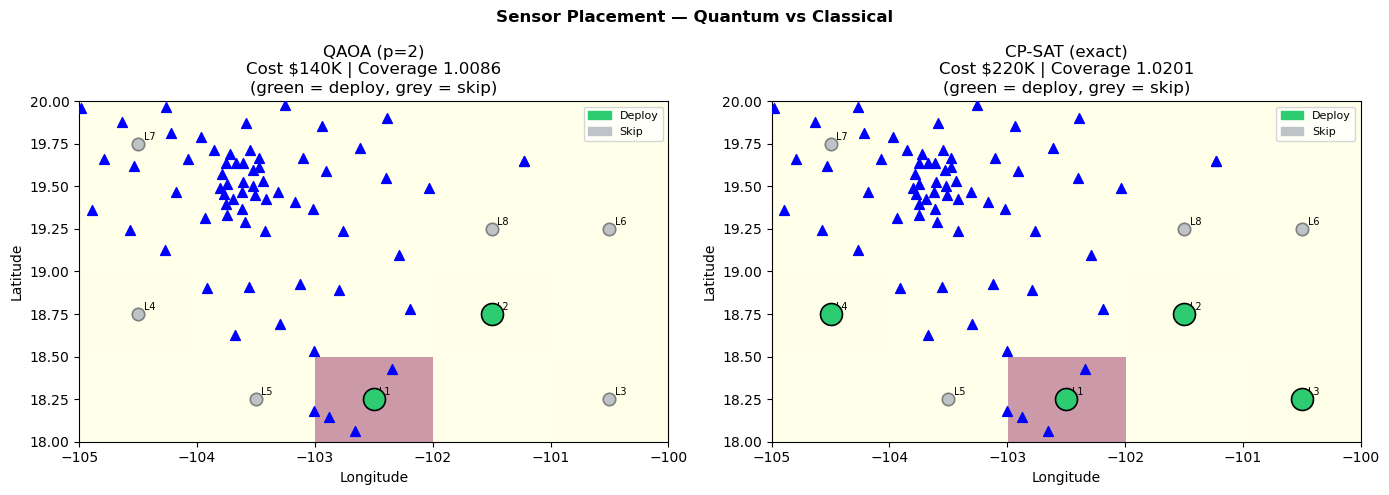

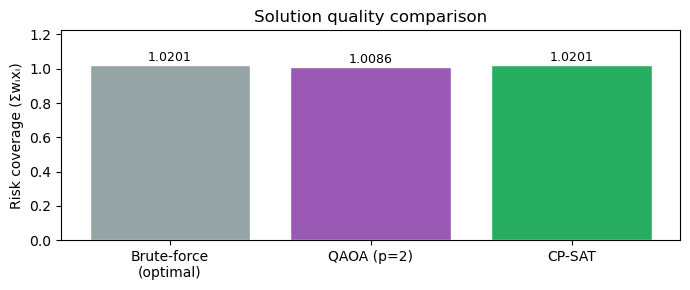

In [29]:
# ── Deployment map ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def plot_deployment(ax, x_arr, label, cost, obj):
    Z = grid.pivot(index="lat_bin", columns="lon_bin", values="risk_norm").values[::-1]
    ax.imshow(Z, cmap="YlOrRd", alpha=0.4, vmin=0, vmax=1,
              extent=[MINLON, MAXLON, MINLAT, MAXLAT], aspect="auto")
    for i, row in candidates.iterrows():
        deployed = bool(x_arr[i])
        color = "#2ecc71" if deployed else "#bdc3c7"
        edge  = "black" if deployed else "gray"
        size  = 250 if deployed else 80
        ax.scatter(row.lon_c, row.lat_c, c=color, s=size,
                   edgecolors=edge, linewidths=1.2, zorder=6)
        ax.annotate(f"L{i+1}", (row.lon_c, row.lat_c),
                    textcoords="offset points", xytext=(4,3), fontsize=7)
    if len(stations):
        ax.scatter(stations.lon, stations.lat, marker="^", c="blue", s=50, zorder=7)
    ax.set_xlim(MINLON, MAXLON); ax.set_ylim(MINLAT, MAXLAT)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title(f"{label}\nCost ${cost*10:.0f}K | Coverage {obj:.4f}\n(green = deploy, grey = skip)")
    deployed_patch = mpatches.Patch(color="#2ecc71", label="Deploy")
    skip_patch     = mpatches.Patch(color="#bdc3c7", label="Skip")
    ax.legend(handles=[deployed_patch, skip_patch], fontsize=8)

plot_deployment(axes[0], best_qaoa_x, f"QAOA (p={P_LAYERS})", best_qaoa_cost, best_qaoa_obj)
plot_deployment(axes[1], cpsat_x,     "CP-SAT (exact)",    cpsat_cost,  cpsat_obj)

plt.suptitle("Sensor Placement — Quantum vs Classical", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Summary bar ───────────────────────────────────────────────────────────────
fig2, ax3 = plt.subplots(figsize=(7, 3))
metrics = {"Brute-force\n(optimal)": best_bf_obj,
           f"QAOA (p={P_LAYERS})": best_qaoa_obj,
           "CP-SAT": cpsat_obj}
colors   = ["#95a5a6", "#9b59b6", "#27ae60"]
ax3.bar(metrics.keys(), metrics.values(), color=colors, edgecolor="white")
ax3.set_ylabel("Risk coverage (Σwᵢxᵢ)")
ax3.set_title("Solution quality comparison")
ax3.set_ylim(0, max(metrics.values())*1.2)
for bar, val in zip(ax3.patches, metrics.values()):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"{val:.4f}",
             ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

## §8  Data Gaps + Deprioritised Sources

### Documented data gap — GNSS/GPS deformation weights
EarthScope GNSS (daily/hourly position time series) would provide **deformation-based risk weights** — physically more meaningful than catalog density because they measure interseismic strain accumulation directly.
- **Status**: preprocessing required (RINEX → position → velocity → strain rate)
- **Action**: flag for Phase II extension; use catalog density as proxy for toy QUBO
- **Impact**: would replace `risk_norm` (seismicity density) with `strain_rate_norm` — same QUBO structure, better physics

### Deprioritised datasets (not in toy QUBO, note for team)
| Dataset | Reason excluded | Future role |
|---------|----------------|-------------|
| Copernicus LAC InSAR | Processing-heavy, regional scope (Latin America), not an event stream | Could provide surface deformation maps as alternative risk weight |
| OpenTopography LiDAR/SfM | Static terrain, not time-series seismic, campaign-dependent | Site selection / geomorphology context for sensor siting |
| Borehole strain/tilt | Sparse, preprocessing-heavy, western-US biased | High-value near-field sensors if budget allows Phase III expansion |
| Copernicus EU EGMS | Europe-only coverage | Not applicable to Manzanillo region |

### Key constraint for team (from Liz's memo)
> QUBO problem size must stay under ~20 binary variables for the simulator to run cleanly.

This experiment uses **13 variables** (8 sensor + 5 slack bits). Adding GNSS deformation weights or a finer grid would increase sensor candidates but not variable count if we keep n ≤ 12 + K_slack ≤ 20.

---

### Next steps
1. **Kernel target alignment** — wrap QUBO risk weights in a quantum kernel feature map (from `quantum_exp.ipynb` QSVM) to see whether the quantum kernel better separates high/low risk cells before placement
2. **Multi-hazard merge** — combine seismic `risk_norm` with Haruka's tsunami risk weights and Michael's wildfire risk weights into a single QUBO objective with hazard-type coefficients
3. **Hardware submission** — re-run QAOA on IBM Quantum via `pennylane-qiskit` device; compare solution quality and runtime at same p=2
4. **ETAS benchmark** — fit ETAS model to historical catalog; use ETAS-predicted M≥5 rates as `wᵢ` alternative
5. **Expand to 15+ sites** — once GNSS deformation preprocessing is done, re-run with 12 candidates + physical weights